# Dataset Unzip

In [15]:
!pip install numpy==1.21.0

In [16]:
import numpy
print(numpy.__version__)

1.21.0


In [17]:
# from google.colab import drive
# drive.mount('/content/drive')

In [18]:
# !cd /content/drive/MyDrive/DL_lab4/
# !unzip /content/drive/MyDrive/DL_lab4/speech_commands.zip -d /content/drive/MyDrive/DL_lab4/

# Training

In [19]:
import sys
import os
current_dir = 'C:/Users/lab423/Desktop/Deep Learn/DL_lab4'
sys.path.append(current_dir)

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from speech_command_dataset import SpeechCommandDataset
from torchvision.transforms import Compose
import torchvision.models as models
import model

# from apex import amp

import os,time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [21]:
torch.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [22]:
EPOCH = 30
BATCH_SIZE = 32
LR = 1e-3
Weight_decay = 1e-9

In [23]:
# declare dataloader
training_params = {"batch_size": BATCH_SIZE,
                       "shuffle": True,
                       "drop_last": False,
                       "num_workers": 1}

testing_params = {"batch_size": BATCH_SIZE,
                       "shuffle": False,
                       "drop_last": False,
                       "num_workers": 1}

train_set = SpeechCommandDataset()
train_loader = DataLoader(train_set, **training_params)

test_set = SpeechCommandDataset(is_training=False)
test_loader = DataLoader(test_set, **testing_params)

In [24]:
# declare network
net = model.SincNet().cuda()
print(net)

SincNet(
  (sincconv): _Layer(
    (conv0): SincConv1d()
    (logabs): LogAbs()
    (bn): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  )
  (features): ModuleList(
    (0): _Layer(
      (conv0): Conv1d(40, 40, kernel_size=(25,), stride=(2,), groups=40)
      (conv1): Conv1d(40, 256, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
      (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    )
    (1): _Layer(
      (conv0): Conv1d(256, 256, kernel_size=(9,), stride=(1,), groups=256)
      (conv1): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
      (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    )
    (2): _Layer(
      (conv0): Conv1d(256, 256,

In [25]:
# declare optimizer and loss function
optimizer = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=Weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,  patience=15, verbose=True, eps=1e-09)

loss_func = nn.CrossEntropyLoss()

In [26]:
print('Begin training...')

best_accuracy = 0
itertion = 0
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []
lr_list = []

for epoch in range(EPOCH):
    net.train()
    start_time = time.time()
    total_train_loss = 0
    total_dloss = 0
    correct = 0
    total = 0
    batch_num = 0

    for step, (audios, labels) in enumerate(tqdm(train_loader, desc="Training", leave=True)):
        audios = audios.cuda()
        labels = labels.cuda()
        outputs = net(audios)

        loss = loss_func(outputs, labels)

        total_train_loss += loss.item()
        batch_num += 1
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    end_time = time.time()
    train_time = end_time - start_time
    train_loss = total_train_loss / batch_num
    train_loss_list.append(train_loss)
    train_acc = 100.0 * float(correct) / float(total)
    train_acc_list.append(train_acc)

    start_time = time.time()
    total_val_loss = 0
    correct = 0
    total = 0
    batch_num = 0

    net.eval()
    for audios, labels in tqdm(test_loader, desc="Testing", leave=True):
        audios = audios.cuda()
        labels = labels.cuda()

        outputs = net(audios)
        loss = loss_func(outputs, labels)

        total_val_loss += loss.item()
        batch_num += 1
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()

    end_time = time.time()
    test_time = end_time-start_time
    val_loss = total_val_loss / batch_num
    val_loss_list.append(val_loss)
    val_acc = 100.0 * float(correct) / float(total)
    val_acc_list.append(val_acc)

    for param_group in optimizer.param_groups:
        lr_list.append(param_group['lr'])


    print(time.strftime("%d %b %Y %H:%M:%S", time.localtime()))
    print('Epoch: %3d' % epoch, '|train loss: %.4f' % train_loss, '|train accuracy: %.2f' % train_acc,
          '|validation loss: %.4f' % val_loss, '|validation accuracy: %.2f' % val_acc,
          '|learning rate: %.1e' % lr_list[-1],
          '|train time: %.2f' % train_time,'|test time: %.2f' % test_time)



    scheduler.step(val_loss)



    if val_acc>best_accuracy:
        print('Saving..')
        torch.save({'cfg': None, 'state_dict': net.state_dict()}, os.path.join('C:/Users/lab423/Desktop/Deep Learn/DL_lab4/Checkpoint', 'SincNet_best.pth.tar'))
        best_accuracy = val_acc


print('Best accuracy: %.2f' % best_accuracy)

Begin training...


Testing: 100%|██████████| 5/5 [00:01<00:00,  2.83it/s]


09 Nov 2024 13:15:45
Epoch:   0 |train loss: 1.8327 |train accuracy: 38.07 |validation loss: 2.2424 |validation accuracy: 19.38 |learning rate: 1.0e-03 |train time: 3.66 |test time: 1.77
Saving..


Testing: 100%|██████████| 5/5 [00:01<00:00,  2.91it/s]


09 Nov 2024 13:15:50
Epoch:   1 |train loss: 1.4769 |train accuracy: 55.11 |validation loss: 2.1099 |validation accuracy: 38.75 |learning rate: 1.0e-03 |train time: 3.40 |test time: 1.72
Saving..


...

09 Nov 2024 13:18:04
Epoch:  27 |train loss: 0.0923 |train accuracy: 97.86 |validation loss: 0.6656 |validation accuracy: 81.25 |learning rate: 1.0e-03 |train time: 3.34 |test time: 1.68


Testing: 100%|██████████| 5/5 [00:01<00:00,  2.97it/s]


09 Nov 2024 13:18:09
Epoch:  28 |train loss: 0.0830 |train accuracy: 98.25 |validation loss: 0.5553 |validation accuracy: 83.75 |learning rate: 1.0e-03 |train time: 3.42 |test time: 1.69
Saving..


Testing: 100%|██████████| 5/5 [00:01<00:00,  2.94it/s]

09 Nov 2024 13:18:14
Epoch:  29 |train loss: 0.0669 |train accuracy: 98.93 |validation loss: 0.6269 |validation accuracy: 81.25 |learning rate: 1.0e-03 |train time: 3.36 |test time: 1.70
Best accuracy: 83.75


Text(0, 0.5, 'lr')

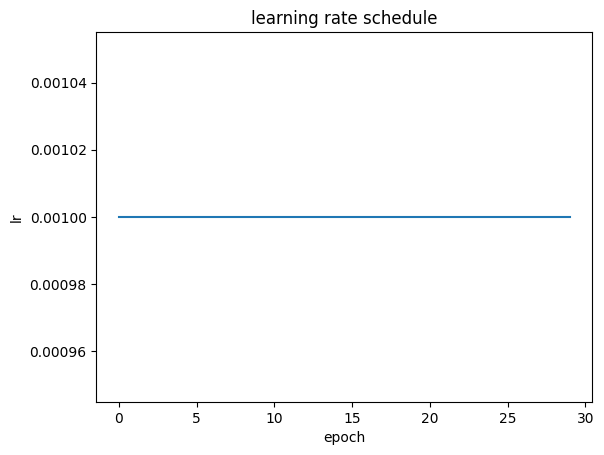

In [27]:
plt.plot(lr_list)

plt.title('learning rate schedule')
plt.xlabel('epoch')
plt.ylabel('lr')

Text(0, 0.5, 'accuracy')

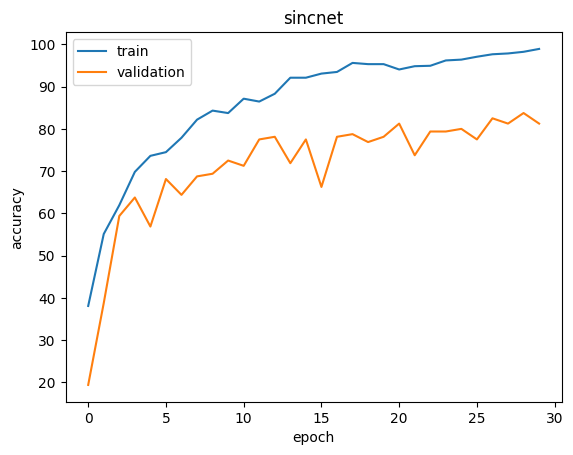

In [28]:
plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.legend(labels=["train", "validation"],loc=0)


plt.title('sincnet')
plt.xlabel('epoch')
plt.ylabel('accuracy')